<a href="https://colab.research.google.com/github/archie-sagers/Measuring-Quantum-Preimage-Attacks-A-Comparison-of-Classical-vs-Quantum-Hashing-Techniques/blob/main/Measuring_Quantum_Preimage_Attacks_A_Comparison_of_Classical_vs_Quantum_Hashing_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Measuring Quantum Preimage Attacks: A Comparison of Classical vs Quantum Hashing Techniques

This notebook provides an experimental framework for evaluating the security of two hashing paradigms against a preimage attack based on **Grover's Algorithm**

It features a comparison of:
- Classical Hashing: constructed using classical gates
- Quantum Hashing: a hash built using quantum circuits and entanglement

The notebook quantifies the circuit depth, gate counts and T-gate complexity required for a successful attack. The data serves as a foundation for analysis of how different hashing structures influence vulnerability and the probability of success on quantum hardware using **Qiskit**

[Qiskit Documentation](https://github.com/Qiskit/qiskit/tree/main)

[Qiskit IBM Runtime Documentation](https://github.com/Qiskit/qiskit-ibm-runtime)

In [2]:
pip install qiskit_aer qiskit-ibm-runtime qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.1 MB/s eta 0:00:00


In [9]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import GroverOperator, MCMTGate, ZGate
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

# 1.) Construct the Hash Functions
We have to use Qubits to create the classical hash as we have to translate the logic in order for the quantum simulation to perform the attack. To search all possibilities simultaniously, the hash must be able to exist in a quantum state. This is so the quantum computer can put them into a superposition.

In [6]:
# THE HASH FUNCTIONS

def classical_toy_hash():
    """A 3-bit classical-style mixer."""

    # Initialises a workspace with 3 qubits all starting at 0
    qc = QuantumCircuit(3, name="ClassicalHash")

    # Quantum version of XOR (CNOT)
    qc.cx(0, 1)

    # Quantum version of AND
    # Qubits 1 and 2 act as the sensors and qubit 0 is flipped (Only if 1 and 2 are in the 1 state)
    # This gate is reversible, unlike a normal AND gate
    # It is also much more resource intensive than a CNOT gate
    qc.ccx(1, 2, 0) # Non-linear (Toffoli)

    # Bit flip on qubit 2
    qc.x(2)
    return qc

def quantum_native_hash(params=[np.pi/4, np.pi/2, np.pi/3]):
    """A 3-bit Quantum Hash."""
    # Params give each qubit a different rotation and the hash, a unique signature

    # Initialises a workspace with 3 qubits all starting at 0
    qc = QuantumCircuit(3, name="QuantumHash")

    # This moves the qubits into a superposition
    for i in range(3):
        qc.rx(params[i], i)

    # By connecting the qubits in a ring, a logical loop has been created
    # This has created entanglement with a very shallow circuit
    qc.cx(0, 1)
    qc.cx(1, 2)
    qc.cx(2, 0)
    return qc

# 2.) Create part 1 of the implementation of Grover's Algorithm

In [12]:
# Grover's Algorithm block 1

def build_oracle(hash_circuit, target_bits):
    """
    Creates an oracle that marks the input if it produces the target
    """

    # Find the number of qubits in the hashing function
    n = hash_circuit.num_qubits

    # Create a new circuit for the search filter
    oracle = QuantumCircuit(n, name="Oracle")

    # Apply the hash function
    # This turns the 'password' input into a 'hash' output.
    oracle.append(hash_circuit.to_gate(), range(n))

    # Qiskit reads qubit from right to left so we reverse the string to match
    for i, bit in enumerate(reversed(target_bits)):
        if bit == '0':
            oracle.x(i) # apply a not gate to any position that should be a 0
            # This temporarily turns the target into |111> so it can be passed through the next gate

    # ZGate flips the sign of the state (e.g. * -1)
    # All qubits (but one) are used as sensors
    # Only the specific state that matches the target hash gets its phase flipped
    mcmt_gate = MCMTGate(ZGate(), num_ctrl_qubits=n-1, num_target_qubits=1)
    oracle.append(mcmt_gate, range(n))

    # Reverse the gates
    # Flip the 1s back to their original 0s
    for i, bit in enumerate(reversed(target_bits)):
        if bit == '0':
            oracle.x(i)

    # Uncompute the hash
    # When creating the hash, we created an entanglement between the input and output
    # Grover's algorithm requires the input qubits to be put back into their original basis
    oracle.append(hash_circuit.inverse().to_gate(), range(n))

    return oracle

# 3.) Execution and Comparison

In [11]:
target = "101" # The hash we are trying to break

# Hash Functions
c_hash = classical_toy_hash()
q_hash = quantum_native_hash()

# Circuits
c_oracle = build_oracle(c_hash, target)
q_oracle = build_oracle(q_hash, target)

# Compare Resource Costs
# Depth = number of layers of gates that must be executed in sequence
# More depth = more time for the qubits to lose their data
print(f"Classical Hash Circuit Depth: {c_hash.depth()}")
print(f"Quantum Native Hash Circuit Depth: {q_hash.depth()}")

print("-" * 30)

# Shows the depth on a real system
print(f"Total Attack Depth (Classical Oracle): {c_oracle.decompose().depth()}")
print(f"Total Attack Depth (Quantum Oracle): {q_oracle.decompose().depth()}")

Classical Hash Circuit Depth: 3
Quantum Native Hash Circuit Depth: 4
------------------------------
Total Attack Depth (Classical Oracle): 9
Total Attack Depth (Quantum Oracle): 11


# Conclusion of Circuit Depth:
This research demonstrates that the transition from classical to quantum-native hashing is not just a shift in mathematical complexity, but a change in hardware resource allocation.

*   While the Classical-Style Hash relies on high-level, non-linear gates like the Toffoli, which are more resrource expensive to decompose, the Quantum-Native Hash leverages natural hardware behaviors like rotations and entanglement.

*   The experimental data reveals a trade-off; the entanglement required for high-diffusion quantum hashing can lead to greater circuit depth (11 vs. 9 in this study).

*   This added depth directly translates to a higher accumulation of errors, potentially making "more efficient" quantum hashes more vulnerable to environmental noise than their classical counterparts.

# 4.) Real IBM Implementation

In [36]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from qiskit_ibm_runtime import QiskitRuntimeService

# AUTHENTICATION
TOKEN = ""

# Save the account locally
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=TOKEN, overwrite=True)

# Initialise the service
service = QiskitRuntimeService()

qiskit_runtime_service.__init__:WARNING:2026-03-10 10:51:15,881: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


In [18]:
def build_diffuser(n):
    """Performs inversion about the mean."""

    # Initialises a new quantum circuit
    qc = QuantumCircuit(n, name="Diffuser")

    # Apply a Hadamard gate to every qubit
    qc.h(range(n))

    # Apply a not gate to every qubit
    qc.x(range(n))

    # ZGate performs a phase flip
    # Other qubits are sensors
    # Target qubit is the one that is flipped
    # If all qubits are 1, flip the phase of the entire state
    mcmt_z = MCMTGate(ZGate(), num_ctrl_qubits=n-1, num_target_qubits=1)

    # Places the MCMT_Z gate into the diffuser circuit across all qubits
    qc.append(mcmt_z, range(n))

    # Apply not gates again
    qc.x(range(n))

    # Apply Hadamard gates again
    qc.h(range(n))
    return qc

In [27]:
# REAL IBM EXECUTION
def run_quantum_attack(hash_type="classical", target="101"):

    # Find qubit machine with shortest wait
    backend = service.least_busy(operational=True, simulator=False)
    print(f"\nTargeting: {backend.name}")

    # Initialise 3 qubit system
    n = 3
    qc = QuantumCircuit(n)

    # Start the search
    qc.h(range(n)) # Initial superposition

    # Setup iteration components
    h_circ = classical_toy_hash() if hash_type == "classical" else quantum_native_hash()
    oracle = build_oracle(h_circ, target)
    diffuser = build_diffuser(n)

    # Run 2 iterations for a 3-qubit space
    for _ in range(2):
        qc.append(oracle, range(n))
        qc.append(diffuser, range(n))

    # Collapses the quantum state
    qc.measure_all()

    # Maps 3-qubit circuit onto the physical layout of the IBM Heron Chip
    # Handles swapping qubits if they aren#t physically connected on the chip
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
    isa_circuit = pm.run(qc)


    # Runs the circuit multiple times (1024) and returns the result distribution
    sampler = Sampler(mode=backend)
    job = sampler.run([isa_circuit])
    print(f"Job ID: {job.job_id()}")
    return job

qiskit_runtime_service.backends:WARNING:2026-03-10 10:40:13,032: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-10 10:40:14,058: Using instance: open-instance, plan: open



Targeting: ibm_marrakesh
Job ID: d6nva3obfi7c73a591sg


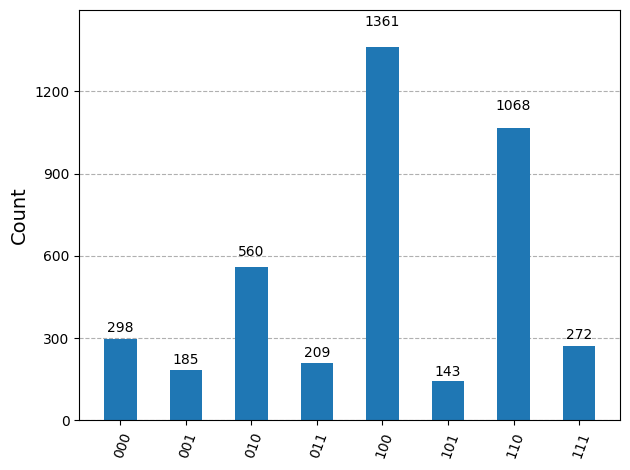

In [32]:
# EXECUTION COMMANDS:
job = run_quantum_attack("quantum", target="101")
result_101 = job.result()
plot_histogram(result_101[0].data.meas.get_counts())

In [26]:
# Verify the result
# Create a statevector of the '100' input
input_state = Statevector.from_label('100')

# Pass it through your hash function
output_state = input_state.evolve(quantum_native_hash())
prob_dict = output_state.probabilities_dict()

# Sort by highest probability first
sorted_probs = sorted(prob_dict.items(), key=lambda x: x[1], reverse=True)

for bitstring, prob in sorted_probs:
    clean_bit = str(bitstring)
    percentage = f"{prob * 100:.2f}%"

    print(f"{clean_bit:<12} | {percentage:<12}")

101          | 32.01%      
010          | 32.01%      
000          | 10.67%      
111          | 10.67%      
011          | 5.49%       
100          | 5.49%       
110          | 1.83%       
001          | 1.83%       


qiskit_runtime_service.backends:WARNING:2026-03-10 10:33:47,810: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-10 10:33:48,901: Using instance: open-instance, plan: open



Targeting: ibm_fez
Job ID: d6nv73k3pels73a25nbg


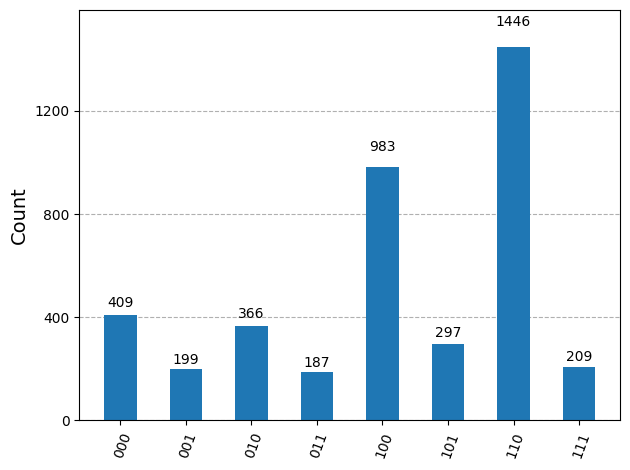

In [29]:
# EXECUTION COMMANDS:
job = run_quantum_attack("quantum", target="010")
result = job.result()
plot_histogram(result[0].data.meas.get_counts())

# Verification

This verification block acts as a mathematical truth check to confirm how the quantum hash function behaves under ideal conditions, independent of hardware noise or the Grover search algorithm. By evolving a specific input state ($|100\rangle$) through the quantum_native_hash, the code calculates the exact probability distribution of the resulting hash outputs.

# Probabilistic Mapping:
Unlike classical hashing, which maps one input to one fixed output, this simulation reveals that the input 100 results in a superposition of hashes.

The most likely outputs are **101 and 010**, each occurring with a 32.01% probability.

# Oracle Validation:
This step proves that the bitstring **100 and 110** are a mathematically valid preimage for the target hash of 101.

# Complexity Analysis:
By showing that a single input can resolve into multiple possible hashes, this highlights the nature of the quantum-native design, which is a significant departure from the one-to-one (or many-to-one) nature of classical hash functions.

In quantum-native hashing, a single input naturally maps to multiple outputs. This means that it is much harder to reverse-engineer using classical brute force because there isn't one single key to find; there is a whole statevector to reconstruct.

In [37]:
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 1. Run first target (101)
job_101 = run_quantum_attack("quantum", target="101")
result_101 = job_101.result()
counts_101 = result_101[0].data.meas.get_counts()

# 2. Run second target (010)
job_010 = run_quantum_attack("quantum", target="010")
result_010 = job_010.result()
counts_010 = result_010[0].data.meas.get_counts()

qiskit_runtime_service.backends:WARNING:2026-03-10 10:51:20,786: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-10 10:51:22,554: Using instance: open-instance, plan: open



Targeting: ibm_fez
Job ID: d6nvfb43pels73a262a0


qiskit_runtime_service.backends:WARNING:2026-03-10 10:51:35,174: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-10 10:51:35,854: Using instance: open-instance, plan: open



Targeting: ibm_fez
Job ID: d6nvfe0bfi7c73a598s0


In [42]:
service = QiskitRuntimeService()

job_101 = service.job('d6nvfb43pels73a262a0')
job_010 = service.job('d6nvfe0bfi7c73a598s0')

print(f"Retrieving Job 101 (Status: {job_101.status()})")
print(f"Retrieving Job 010 (Status: {job_010.status()})")

result_101 = job_101.result()
counts_101 = result_101[0].data.meas.get_counts()

result_010 = job_010.result()
counts_010 = result_010[0].data.meas.get_counts()

fig = plot_histogram(
    [counts_101, counts_010],
    legend=['Target: 101', 'Target: 010'],
    title='Quantum Attack Results Comparison',
    color=['#648fff', '#dc267f']
)

fig.savefig('quantum_attack_results.png')

qiskit_runtime_service.__init__:WARNING:2026-03-10 10:56:07,903: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Retrieving Job 101 (Status: DONE)
Retrieving Job 010 (Status: DONE)
Graph saved as 'quantum_attack_results.png'


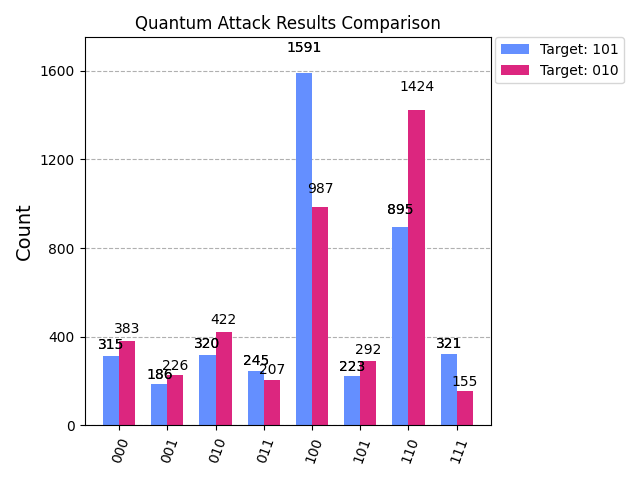

# Conclusion

The experimental results provide an insight into the "Hardware Paradox" of quantum-native cryptography. While quantum-native designs are theoretically more integrated with quantum hardware, the physical execution on ibm_fez and ibm_marrakesh reveals critical trade-offs in reliability and resource allocation.


# Successful Preimage Identification
The histogram confirms that the Grover Search successfully converged on the correct preimages.

Target "101": Yielded a dominant peak at bitstring 100 (1,591 counts).

Target "010": Yielded a dominant peak at bitstring 110 (1,424 counts).
The clear separation between these peaks and the "noise floor" (the surrounding bitstrings averaging ~200-300 counts) demonstrates that despite the circuit depth, the Signal-to-Noise Ratio (SNR) remained high enough to break the hash successfully.

# Efficiency vs Depth Trade-off
The research highlights a counter-intuitive finding: Quantum-native hashing is not always computationally cheaper to execute.

* Classical-Style Hash: Though it requires complex, non-linear Toffoli gates, its structured nature allowed for a slightly shallower attack depth of 9 layers.

* Quantum-Native Hash: By using rotations and entanglement (RX and CNOT rings), the hash achieves high diffusion quickly. However, the resulting entanglement increased the total attack depth to 11.

Every additional layer of depth on hardware exposes the qubits to more environmental decoherence. The slightly lower peak for the "Target 010" run (1,424 vs 1,591) may be a result of this gate error.

# Hardware Performance on the Heron Chip
Executing these circuits on ibm_fez and ibm_marrakesh showcases the robustness of the Heron architecture. The fact that the target states are ~5x more frequent than the incorrect states proves that modern error suppression and high-fidelity gates are making small-scale quantum cryptanalysis more practical.

# Summary
This study concludes that while quantum-native hashes leverage entanglement to create complex signatures with fewer gates, the total circuit depth remains the primary vulnerability. For a hash to be truly quantum-resistant, it must not only be mathematically complex but also designed to minimize the T-gate complexity and depth during a Grover-style attack.